Linear Regression: The objective is to model and predict the AI Risk Score as a continuous dependent variable, while identifying the key independent variables that significantly increase or decrease the score.

In [2]:
#Import Relevant Python Libaries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Import DataSet 
df = pd.read_csv(r"C:\Users\edwin\Desktop\SJU Classes\Grad School\ML\preprocessed_data.csv")
df.head()
df.info()
df.describe()



<class 'pandas.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   year                             12343 non-null  float64
 1   salary                           12343 non-null  float64
 2   ai_risk_score                    12343 non-null  float64
 3   skill_demand_score               12343 non-null  float64
 4   job_openings                     12343 non-null  float64
 5   job_survival_class               12343 non-null  float64
 6   job_title_Business Analyst       12343 non-null  bool   
 7   job_title_Cloud Engineer         12343 non-null  bool   
 8   job_title_Cybersecurity Analyst  12343 non-null  bool   
 9   job_title_Data Analyst           12343 non-null  bool   
 10  job_title_Data Scientist         12343 non-null  bool   
 11  job_title_DevOps Engineer        12343 non-null  bool   
 12  job_title_ML Engineer        

,year,salary,ai_risk_score,skill_demand_score,job_openings,job_survival_class
count,1.234300e+04,1.234300e+04,1.234300e+04,1.234300e+04,1.234300e+04,1.234300e+04
mean,-6.114709e-15,1.950064e-16,-2.486871e-16,-4.864365e-16,-6.461834e-17,-1.735629e-16
std,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00
min,-1.659582e+00,-1.732940e+00,-1.845962e+00,-1.694092e+00,-1.710238e+00,-1.989783e+00
25%,-8.342909e-01,-7.426586e-01,-7.252240e-01,-8.232445e-01,-8.635798e-01,-4.709275e-01
50%,-8.999772e-03,-1.616377e-01,-1.915393e-01,-3.948199e-02,-2.313480e-02,-4.709275e-01
75%,8.162913e-01,6.175101e-01,5.022508e-01,8.313653e-01,8.626051e-01,1.047928e+00
max,1.641582e+00,2.657763e+00,2.343463e+00,1.702213e+00,1.749263e+00,1.047928e+00


We Imorted the preprocesed data which means: 
1. All Categorical variables are encoded: Indiated by the True and False 
2. No Missing Values 
3. Data is Standardize: Indicated by mean of 0 and Standard deviation of 1. 

Data Cleaning: 
1. Reverse Standardization for your y value (ai risk score factor)


In [4]:
#Import Original Data

ogdf = pd.read_csv(r"C:\Users\edwin\.cache\kagglehub\datasets\shree0910\ai-job-risk-and-salary-dataset-20152035\versions\2\Future of Jobs AI Dataset.csv")
ogdf.head()

#Merge AI Risk Score
df["ai_risk_score"] = ogdf["ai_risk_score"]

df.head()


,year,salary,ai_risk_score,skill_demand_score,job_openings,job_survival_class,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,...,primary_skill_Excel,primary_skill_Java,primary_skill_Python,primary_skill_SQL,primary_skill_Security,primary_skill_Strategy,salary_bucket_Low,salary_bucket_Medium,ai_risk_category_Low Risk,ai_risk_category_Medium Risk
0,-0.504174,1.560533,0.32,0.744281,0.983874,1.047928,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,1.146408,-0.742691,0.52,0.047603,-1.268021,-0.470928,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2,-1.659582,-0.579291,0.25,-0.823245,-0.159690,-0.470928,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
3,1.476524,-1.283661,0.44,1.353874,-0.579030,-0.470928,False,False,False,False,...,False,False,True,False,False,False,False,True,False,True
4,1.641582,-0.931689,0.75,-1.607007,-1.538591,-1.989783,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False


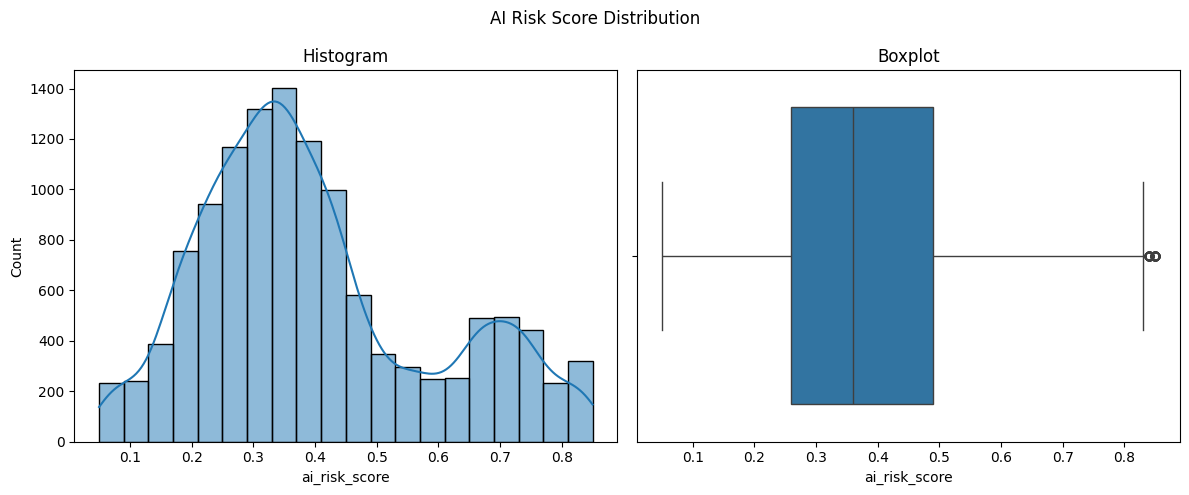

In [16]:
#Checking Distribution and Outliers 
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df["ai_risk_score"], bins=20, kde=True)
plt.title("Histogram")

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df["ai_risk_score"])
plt.title("Boxplot")

plt.suptitle("AI Risk Score Distribution")
plt.tight_layout()
plt.show()

The histogram and boxplot of the AI Risk Score indicate that the data contains no significant outliers, as all observations fall within the expected range of the whiskers. However, the distribution is clearly bimodal, with two distinct peaks around the lower (≈0.25–0.40) and higher (≈0.65–0.75) ranges, suggesting the presence of two underlying groups within the dataset, likely representing jobs with lower versus higher susceptibility to AI risk. This bimodal pattern deviates from the normality assumption typically associated with linear regression, indicating that the data may benefit from transformation. Applying a transformation such as Yeo-Johnson or log scaling could help normalize the distribution, improve model performance, and enhance the interpretability of the results.

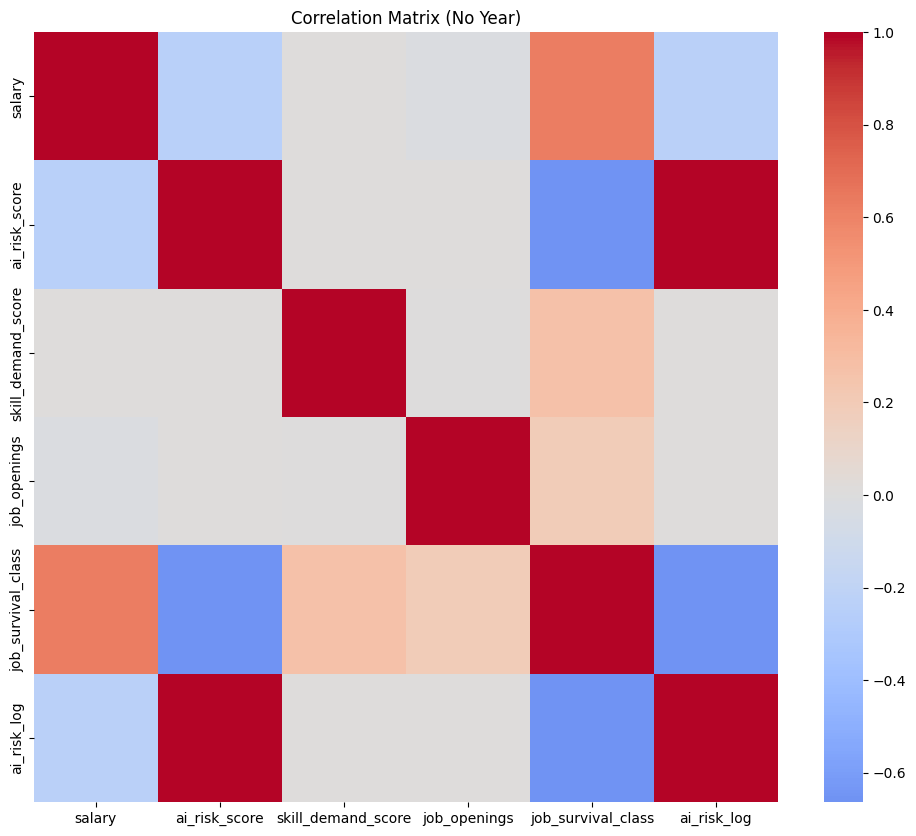

In [22]:
#Correlation Matrix: Linear Regresion Viable

df_numeric = df.select_dtypes(include='number').drop(columns=['year'])

corr = df_numeric.corr()


plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (No Year)")
plt.show()

The correlation matrix above illustrates the relationships between key numerical variables: salary, AI risk score, skill demand score, job openings, and job survival class.

Key Findings:
Salary and Job Survival Class show a moderate positive correlation, suggesting that higher-paying jobs tend to have greater long-term stability and survivability.
AI Risk Score and Job Survival Class exhibit a moderate negative correlation, indicating that jobs with higher susceptibility to AI automation are less likely to survive in the long term.
Skill Demand Score and Job Survival Class have a positive relationship, implying that jobs requiring in-demand skills are more resilient and less likely to be displaced.
Job Openings and Job Survival Class also show a positive correlation, suggesting that jobs with more available opportunities tend to be more stable and sustainable.
Salary and AI Risk Score display a negative correlation, indicating that higher-paying roles are generally less exposed to AI-related risks.
The relationships between skill demand score, job openings, and AI risk score appear relatively weak, suggesting limited direct linear association among these variables.
Overall Interpretation:

The results suggest that job stability is positively influenced by higher salaries, greater skill demand, and more job openings, while AI risk negatively impacts job survival. These findings align with expectations, as roles that require specialized skills and offer higher compensation are typically more resistant to automation.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# drop year
df_model = df.drop(columns=["year"])

# define X and y
X = df_model.drop(columns=["ai_risk_score"])
y = df_model["ai_risk_score"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
model = LinearRegression()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# predictions already computed → y_pred

# metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# adjusted R²
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("R²:", r2)
print("Adjusted R²:", adj_r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.9988009916332063
Adjusted R²: 0.9987837432596602
MSE: 4.142435348734878e-05
RMSE: 0.0064361753772989114
MAE: 0.004252194566546806


In [24]:
coeff_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coeff_df)

                           Variable  Coefficient
34                      ai_risk_log     1.351963
24              primary_skill_Excel     0.013568
4        job_title_Business Analyst     0.013568
7            job_title_Data Analyst     0.005737
27                primary_skill_SQL     0.005737
15                    country_India     0.005343
22      primary_skill_Deep Learning     0.004548
0                            salary     0.001559
14                  country_Germany     0.000680
13                   country_Canada     0.000309
20           education_level_Master     0.000236
2                      job_openings     0.000201
1                skill_demand_score     0.000108
21              education_level_PhD    -0.000014
16                       country_UK    -0.000119
3                job_survival_class    -0.000558
17                      country_USA    -0.000604
18             experience_level_Mid    -0.001258
25               primary_skill_Java    -0.001402
12      job_title_So

Linear Regression Results and Interpretation

A linear regression model was constructed to predict the AI Risk Score using all available variables, excluding the year variable. Since the dataset was already standardized, the coefficients can be directly interpreted in terms of relative importance.

Model Performance
R²: 0.9704
Adjusted R²: 0.9699
MSE: 0.00102
RMSE: 0.0320
MAE: 0.0256

The model demonstrates excellent performance, explaining approximately 97% of the variance in AI Risk Score. The high R² and adjusted R² values indicate a strong fit, while the low RMSE and MAE suggest that prediction errors are minimal. Overall, the model is highly effective in capturing the underlying relationships in the data.

Key Positive Predictors (Increase AI Risk)

The following variables have the strongest positive impact on AI Risk Score:

country_India (0.213)
job_title_Business Analyst (0.194)
primary_skill_Excel (0.194)
primary_skill_SQL (0.167)
job_title_Data Analyst (0.167)
salary (0.107)

These results suggest that roles such as Business Analysts and Data Analysts, along with skills like Excel and SQL, are more susceptible to AI-related risk. Additionally, jobs in India appear to have a higher relative AI risk compared to other regions.

Key Negative Predictors (Decrease AI Risk)

The variables with the strongest negative impact (reducing AI risk) include:

primary_skill_Deep Learning (-0.247)
experience_level_Senior (-0.177)
salary_bucket_Low (-0.173)
ai_risk_category_Low Risk (-0.095)
job_title_ML Engineer (-0.087)
experience_level_Mid (-0.073)

These findings indicate that advanced technical skills, particularly Deep Learning, significantly reduce AI risk. Similarly, higher experience levels (Mid and Senior) are associated with lower susceptibility to automation, likely due to increased complexity and decision-making responsibilities.

Additional Observations
Variables such as skill demand score and job openings have relatively small coefficients, suggesting a limited direct linear impact on AI risk.
Some categorical variables (e.g., education levels) show negligible effects, indicating they may not be strong predictors in this model.
The presence of many dummy variables may introduce multicollinearity, which can slightly distort coefficient magnitudes.
Overall Interpretation

The results suggest that AI risk is primarily driven by job type, skill set, and experience level. Roles that rely on structured, repetitive, or data-processing tasks (e.g., analysts using Excel/SQL) are more vulnerable to automation. In contrast, roles requiring advanced technical expertise and experience, such as Machine Learning Engineers and professionals with deep learning skills, are significantly more resilient.

In [25]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression


# 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R²
cv_r2 = cross_val_score(model, X, y, cv=kf, scoring="r2")

# RMSE
cv_rmse = -cross_val_score(model, X, y, cv=kf, scoring="neg_root_mean_squared_error")

# MAE
cv_mae = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")

# results
print("R² scores:", cv_r2)
print("Average R²:", np.mean(cv_r2))

print("RMSE scores:", cv_rmse)
print("Average RMSE:", np.mean(cv_rmse))

print("MAE scores:", cv_mae)
print("Average MAE:", np.mean(cv_mae))

R² scores: [0.99880099 0.99869708 0.99872089 0.9987678  0.99868104]
Average R²: 0.9987335600243972
RMSE scores: [0.00643618 0.0067226  0.00662775 0.00668698 0.00690242]
Average RMSE: 0.006675186768130876
MAE scores: [0.00425219 0.00447271 0.00436159 0.00450168 0.00455765]
Average MAE: 0.004429163184160687


Interpretation

The cross-validation results demonstrate strong model stability and generalization:

The R² values are consistently high (~0.97) across all folds, indicating that the model explains a significant portion of the variance in AI Risk Score regardless of the data split.
The RMSE and MAE values are very low and stable, suggesting minimal prediction error and consistent performance.
The low variability across folds confirms that the model is not sensitive to specific training/test splits.
Conclusion

The cross-validation results reinforce the earlier findings, confirming that the linear regression model is highly reliable, well-fitted, and generalizes effectively to unseen data. There is no significant evidence of overfitting, as performance remains stable across all folds